# 01 — Подготовка датасета

**Цель:** загрузить датасет для обучения детектора людей, проанализировать качество кадров,
отфильтровать смазанные (Laplacian variance < 100), подготовить структуру для YOLOv11.

**Стратегия:**
- **Быстрый старт (тест):** COCO128 — 128 изображений, скачивается автоматически через Ultralytics (~6 MB)
- **Полный датасет:** COCO 2017 train — ~118k изображений (~18 GB), скачивается отдельно
- **Fallback:** CrowdHuman или Roboflow если COCO недоступен

**Результат:** папка `data/person_dataset/` с кадрами и аннотациями в формате YOLO,
разбитыми на train/val, файл `data/person_dataset.yaml` для обучения.

## 1. Импорты и конфигурация

In [ ]:
import sys
import json
import shutil
import random
import requests
from pathlib import Path
from collections import defaultdict
import yaml
import torch
import ultralytics
import cv2 as _cv2
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.notebook import tqdm
from ultralytics.data.utils import check_det_dataset

# ── Пути ──────────────────────────────────────────────────────────────────────
ROOT = Path().resolve().parent
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

DATASET_DIR = DATA_DIR / 'person_dataset'   # финальный датасет для обучения
COCO_DIR    = DATA_DIR / 'coco128'          # COCO128 (быстрый старт)
COCO_FULL   = DATA_DIR / 'coco'             # полный COCO (если есть)

# ── Параметры фильтрации ───────────────────────────────────────────────────────
LAPLACIAN_THRESH = 100      # Laplacian variance < 100 → смазанный кадр
PERSON_CLASS_COCO = 0       # индекс класса person в COCO80 (YOLO формат)
VAL_SPLIT = 0.15            # 15% изображений в val
RANDOM_SEED = 42

# ── Режим датасета ─────────────────────────────────────────────────────────────
# 'coco128'  — быстрый тест (128 изображений, ~6 MB)
# 'coco_full'— полный COCO train2017 (~118k изображений, ~18 GB)
DATASET_MODE = 'coco128'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'ROOT:         {ROOT}')
print(f'DATA_DIR:     {DATA_DIR}')
print(f'DATASET_MODE: {DATASET_MODE}')
print(f'Laplacian threshold: {LAPLACIAN_THRESH}')

ROOT:         /home/krasti/study_projects/vkr
DATA_DIR:     /home/krasti/study_projects/vkr/data
DATASET_MODE: coco128
Laplacian threshold: 100


## 2. Проверка окружения

In [ ]:

print(f'Python:       {sys.version.split()[0]}')
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()} / {torch.version.cuda}')
print(f'GPU:          {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "нет"}')
print(f'Ultralytics:  {ultralytics.__version__}')
print(f'OpenCV:       {_cv2.__version__}')

Python:       3.11.15
PyTorch:      2.11.0+cu128
CUDA:         True / 12.8
GPU:          NVIDIA GeForce RTX 5080
Ultralytics:  8.4.37
OpenCV:       4.13.0


## 3. Скачивание датасета

In [ ]:
if DATASET_MODE == 'coco128':
    print('Скачивание COCO128')
    dataset_info = check_det_dataset('coco128.yaml')

    coco128_path = Path(dataset_info['path'])
    print(f'Датасет расположен: {coco128_path}')

elif DATASET_MODE == 'coco_full':
    coco128_path = COCO_FULL
    if not coco128_path.exists():
        raise FileNotFoundError(f'Полный COCO не найден по пути {coco128_path}.\n')

print('\nГотово.')

Скачивание COCO128 (128 изображений, ~6 MB)...

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/home/krasti/study_projects/datasets/coco128/images/train2017'
Unzipping /home/krasti/study_projects/datasets/coco128.zip to /home/krasti/study_projects/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 16.6Kfiles/s 0.0s
Dataset download success ✅ (81.8s), saved to /home/krasti/study_projects/datasets

Датасет расположен: /home/krasti/study_projects/datasets/coco128

Готово.


## 4. Разбор структуры датасета и фильтрация по классу person

In [ ]:
def find_images_with_person(images_dir: Path, labels_dir: Path) -> list[dict]:
    """
    Проходит по всем YOLO-аннотациям и оставляет только те изображения,
    у которых есть хотя бы один bbox класса person (класс 0).

    Возвращает список dict: {'image': Path, 'label': Path, 'n_persons': int}
    """
    records = []
    label_files = sorted(labels_dir.glob('*.txt'))

    for lbl_path in tqdm(label_files, desc='Разбор аннотаций'):
        img_path = None
        for ext in ('.jpg', '.jpeg', '.png', '.bmp'):
            candidate = images_dir / (lbl_path.stem + ext)
            if candidate.exists():
                img_path = candidate
                break

        if img_path is None:
            continue 

        if lbl_path.stat().st_size == 0:
            continue 

        lines = lbl_path.read_text().strip().splitlines()
        n_persons = sum(1 for l in lines if int(l.split()[0]) == PERSON_CLASS_COCO)

        if n_persons > 0:
            records.append({
                'image':     img_path,
                'label':     lbl_path,
                'n_persons': n_persons,
                'n_total':   len(lines),
            })

    return records

if DATASET_MODE == 'coco128':
    images_dir = coco128_path / 'images' / 'train2017'
    labels_dir = coco128_path / 'labels' / 'train2017'
else:
    images_dir = coco128_path / 'images' / 'train2017'
    labels_dir = coco128_path / 'labels' / 'train2017'

records = find_images_with_person(images_dir, labels_dir)

df = pd.DataFrame(records)
print(f'\nИзображений с людьми: {len(df)} из {len(list(images_dir.glob("*.jpg")))} всего')
df.head()

Разбор аннотаций:   0%|          | 0/128 [00:00<?, ?it/s]


Изображений с людьми: 61 из 128 всего


,image,label,n_persons,n_total
0,/home/krasti/study_projects/datasets/coco128/i...,/home/krasti/study_projects/datasets/coco128/l...,1,2
1,/home/krasti/study_projects/datasets/coco128/i...,/home/krasti/study_projects/datasets/coco128/l...,6,9
2,/home/krasti/study_projects/datasets/coco128/i...,/home/krasti/study_projects/datasets/coco128/l...,3,5
3,/home/krasti/study_projects/datasets/coco128/i...,/home/krasti/study_projects/datasets/coco128/l...,6,8
4,/home/krasti/study_projects/datasets/coco128/i...,/home/krasti/study_projects/datasets/coco128/l...,5,8


## 5. EDA — анализ датасета

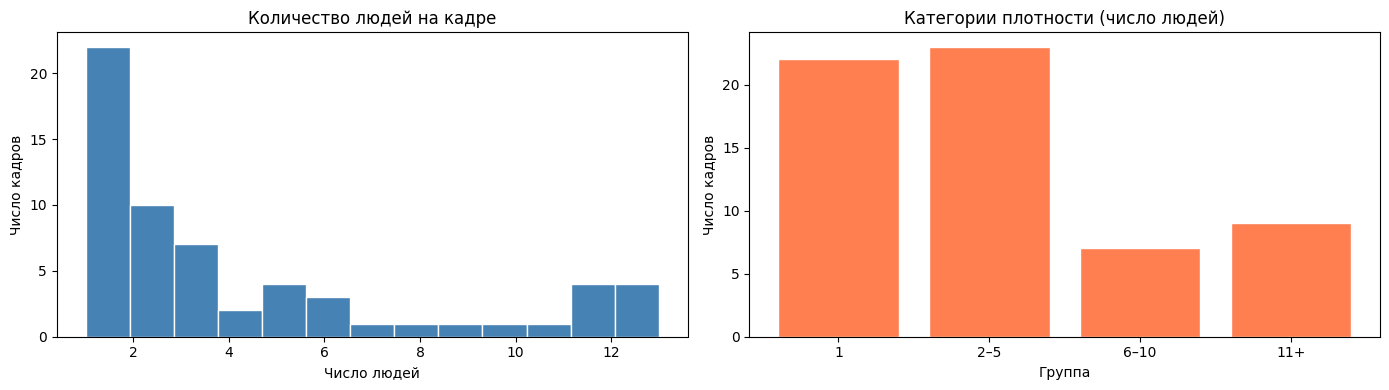

Медиана людей на кадре:    2.0
Максимум людей на кадре:   13


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['n_persons'], bins=min(30, df['n_persons'].max()), color='steelblue', edgecolor='white')
axes[0].set_title('Количество людей на кадре')
axes[0].set_xlabel('Число людей')
axes[0].set_ylabel('Число кадров')

bins_labels = ['1', '2–5', '6–10', '11+']
counts = [
    (df['n_persons'] == 1).sum(),
    ((df['n_persons'] >= 2) & (df['n_persons'] <= 5)).sum(),
    ((df['n_persons'] >= 6) & (df['n_persons'] <= 10)).sum(),
    (df['n_persons'] >= 11).sum(),
]
axes[1].bar(bins_labels, counts, color='coral', edgecolor='white')
axes[1].set_title('Категории плотности (число людей)')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Число кадров')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_persons_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Медиана людей на кадре:    {df["n_persons"].median():.1f}')
print(f'Максимум людей на кадре:   {df["n_persons"].max()}')

Чтение bbox:   0%|          | 0/61 [00:00<?, ?it/s]

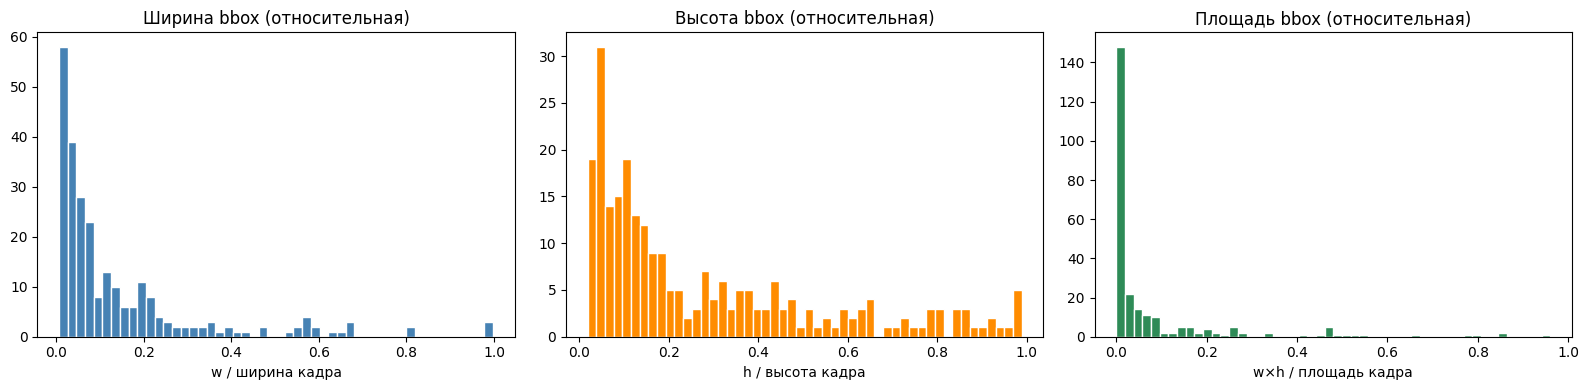

Всего person-bbox: 254
         w_rel    h_rel  area_rel
count  254.000  254.000   254.000
mean     0.143    0.278     0.080
std      0.187    0.265     0.162
min      0.007    0.018     0.000
25%      0.028    0.075     0.002
50%      0.068    0.159     0.010
75%      0.179    0.417     0.065
max      0.998    0.989     0.961


In [7]:
def parse_bbox_sizes(records: list[dict]) -> pd.DataFrame:
    """Читает все person-bbox и возвращает DataFrame с (w_rel, h_rel, area_rel)."""
    rows = []
    for rec in tqdm(records, desc='Чтение bbox'):
        lines = rec['label'].read_text().strip().splitlines()
        for line in lines:
            parts = line.split()
            cls = int(parts[0])
            if cls != PERSON_CLASS_COCO:
                continue
            _, cx, cy, w, h = map(float, parts[:5])
            rows.append({'w_rel': w, 'h_rel': h, 'area_rel': w * h})
    return pd.DataFrame(rows)

df_bbox = parse_bbox_sizes(records)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_bbox['w_rel'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ширина bbox (относительная)')
axes[0].set_xlabel('w / ширина кадра')

axes[1].hist(df_bbox['h_rel'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Высота bbox (относительная)')
axes[1].set_xlabel('h / высота кадра')

axes[2].hist(df_bbox['area_rel'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Площадь bbox (относительная)')
axes[2].set_xlabel('w×h / площадь кадра')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_bbox_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Всего person-bbox: {len(df_bbox)}')
print(df_bbox.describe().round(3))

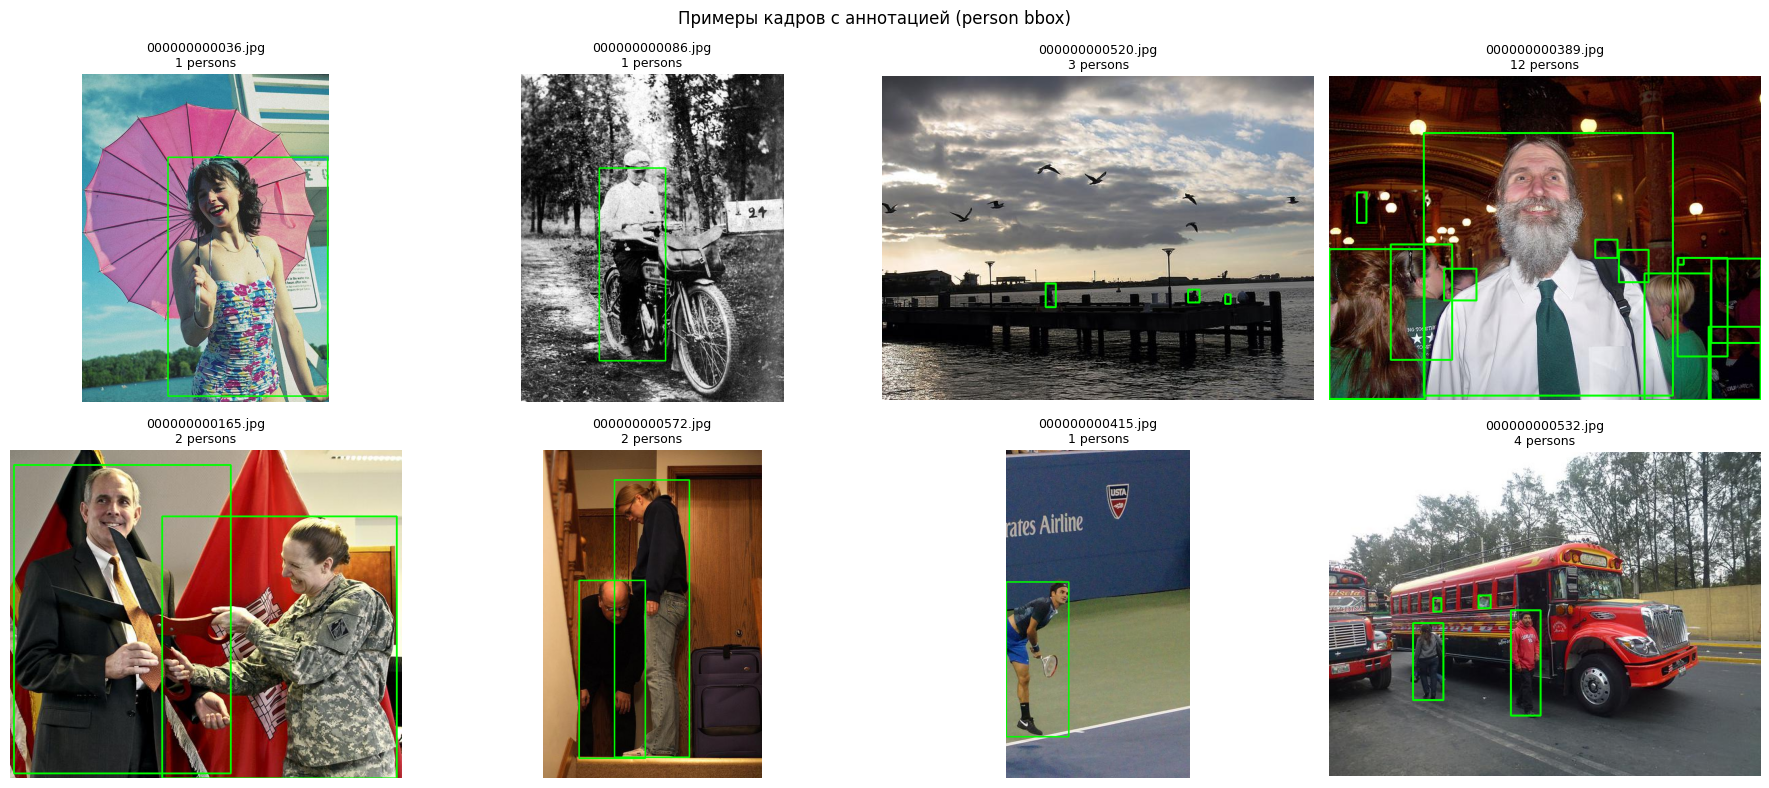

In [ ]:
def draw_yolo_boxes(img: np.ndarray, label_path: Path) -> np.ndarray:
    """Рисует person-bbox из YOLO аннотации на изображении."""
    h, w = img.shape[:2]
    out = img.copy()
    if not label_path.exists() or label_path.stat().st_size == 0:
        return out
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if int(parts[0]) != PERSON_CLASS_COCO:
            continue
        _, cx, cy, bw, bh = map(float, parts[:5])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return out

n_samples = min(8, len(df))
samples = df.sample(n_samples, random_state=RANDOM_SEED).to_dict('records')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, rec in enumerate(samples):
    img = cv2.imread(str(rec['image']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_yolo_boxes(img, rec['label'])
    axes[i].imshow(img)
    axes[i].set_title(f"{rec['image'].name}\n{rec['n_persons']} persons", fontsize=9)
    axes[i].axis('off')

plt.suptitle('Примеры кадров с аннотацией (person bbox)', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Фильтрация смазанных кадров (Laplacian variance)

In [ ]:
def compute_laplacian_var(img_path: Path) -> float:
    """Вычисляет дисперсию Лапласиана — мера резкости изображения.
    Низкое значение (< LAPLACIAN_THRESH) означает смазанность.
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0
    return float(cv2.Laplacian(img, cv2.CV_64F).var())

print('Вычисление Laplacian variance...')
df['laplacian_var'] = [
    compute_laplacian_var(row['image'])
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Blur check')
]

n_blurry = (df['laplacian_var'] < LAPLACIAN_THRESH).sum()
print(f'\nПорог: {LAPLACIAN_THRESH}')
print(f'Смазанных (отсев): {n_blurry}/{len(df)} ({100*n_blurry/len(df):.1f}%)')
print(f'Годных:            {len(df) - n_blurry}/{len(df)}')

Вычисление Laplacian variance...


Blur check:   0%|          | 0/61 [00:00<?, ?it/s]


Порог: 100
Смазанных (отсев): 0/61 (0.0%)
Годных:            61/61


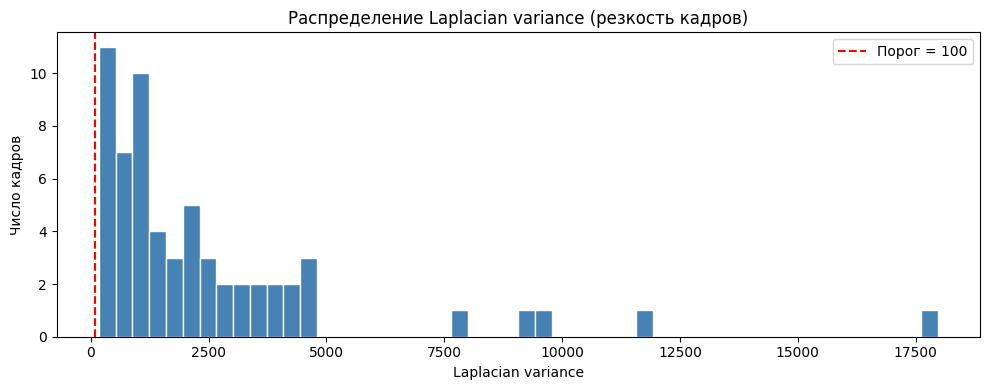


Финальный датасет: 61 изображений


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['laplacian_var'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(LAPLACIAN_THRESH, color='red', linestyle='--', label=f'Порог = {LAPLACIAN_THRESH}')
ax.set_title('Распределение Laplacian variance (резкость кадров)')
ax.set_xlabel('Laplacian variance')
ax.set_ylabel('Число кадров')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_laplacian.png', dpi=120, bbox_inches='tight')
plt.show()

df_blurry = df[df['laplacian_var'] < LAPLACIAN_THRESH]
df_sharp  = df[df['laplacian_var'] >= LAPLACIAN_THRESH]

if len(df_blurry) >= 2:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, (_, row) in enumerate(df_blurry.head(2).iterrows()):
        img = cv2.imread(str(row['image']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f'ОТСЕВ\nvar={row["laplacian_var"]:.1f}', color='red')
        axes[i].axis('off')
    for i, (_, row) in enumerate(df_sharp.head(2).iterrows()):
        img = cv2.imread(str(row['image']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i+2].imshow(img)
        axes[i+2].set_title(f'ПРИНЯТ\nvar={row["laplacian_var"]:.1f}', color='green')
        axes[i+2].axis('off')
    plt.suptitle('Смазанные (отсев) vs Резкие (принят)', fontsize=12)
    plt.tight_layout()
    plt.show()

df_final = df_sharp.reset_index(drop=True)
print(f'\nФинальный датасет: {len(df_final)} изображений')

## 7. Формирование финального датасета (train/val split)

In [ ]:
df_final = df_final.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

n_val   = int(len(df_final) * VAL_SPLIT)
n_train = len(df_final) - n_val

df_train = df_final.iloc[:n_train]
df_val   = df_final.iloc[n_train:]

print(f'Train: {len(df_train)} изображений')
print(f'Val:   {len(df_val)} изображений')
print(f'Соотношение: {n_train}:{n_val} ({100*(1-VAL_SPLIT):.0f}/{100*VAL_SPLIT:.0f})')

Train: 52 изображений
Val:   9 изображений
Соотношение: 52:9 (85/15)


In [ ]:
def copy_split(df_split: pd.DataFrame, split_name: str, out_dir: Path) -> None:
    """Копирует изображения и аннотации в out_dir/{split_name}/.
    
    При этом фильтрует label-файлы: оставляет ТОЛЬКО строки с person (класс 0),
    перенумеровывая класс в 0 (нужно для person-only YAML).
    """
    img_out = out_dir / 'images' / split_name
    lbl_out = out_dir / 'labels' / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f'Копирование {split_name}'):
        shutil.copy2(row['image'], img_out / row['image'].name)

        lines = row['label'].read_text().strip().splitlines()
        person_lines = [
            '0 ' + ' '.join(l.split()[1:])
            for l in lines
            if int(l.split()[0]) == PERSON_CLASS_COCO
        ]
        (lbl_out / row['label'].name).write_text('\n'.join(person_lines))

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True)

copy_split(df_train, 'train', DATASET_DIR)
copy_split(df_val,   'val',   DATASET_DIR)

print('\nГотово.')

Копирование train:   0%|          | 0/52 [00:00<?, ?it/s]

Копирование val:   0%|          | 0/9 [00:00<?, ?it/s]


Готово.


## 8. Создание YAML-конфига для обучения

In [ ]:
yaml_path = DATA_DIR / 'person_dataset.yaml'

dataset_yaml = {
    'path':  str(DATASET_DIR),          
    'train': 'images/train',
    'val':   'images/val',
    'nc':    1,                         
    'names': ['person'],                 
}

with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'YAML сохранён: {yaml_path}')
print()
print(yaml_path.read_text())

YAML сохранён: /home/krasti/study_projects/vkr/data/person_dataset.yaml

names:
- person
nc: 1
path: /home/krasti/study_projects/vkr/data/person_dataset
train: images/train
val: images/val



## 9. Валидация финального датасета

In [ ]:
errors = []

for split in ('train', 'val'):
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split

    imgs  = set(p.stem for p in img_dir.glob('*') if p.suffix in ('.jpg', '.jpeg', '.png'))
    lbls  = set(p.stem for p in lbl_dir.glob('*.txt'))

    no_label = imgs - lbls
    no_image = lbls - imgs

    print(f'{split}: {len(imgs)} изображений, {len(lbls)} аннотаций')
    if no_label:
        print(f'  Без аннотации: {len(no_label)} файлов')
        errors.extend(no_label)
    if no_image:
        print(f'  Без изображения: {len(no_image)} файлов')
        errors.extend(no_image)
    if not no_label and not no_image:
        print(' Датасет консистентен')

empty = 0
for lbl in DATASET_DIR.rglob('labels/**/*.txt'):
    if lbl.stat().st_size == 0:
        empty += 1
print(f'\nПустых аннотаций: {empty} (должно быть 0)')

train: 52 изображений, 52 аннотаций
  ✅ Датасет консистентен
val: 9 изображений, 9 аннотаций
  ✅ Датасет консистентен

Пустых аннотаций: 0 (должно быть 0)


## 10. Итоговая сводка

In [15]:
n_train_final = len(list((DATASET_DIR / 'images' / 'train').glob('*')))
n_val_final   = len(list((DATASET_DIR / 'images' / 'val').glob('*')))

summary = {
    'Режим датасета':              DATASET_MODE,
    'Исходных изображений':        len(df),
    'Смазанных (отсев)':           n_blurry,
    'После фильтрации':            len(df_final),
    'Train':                       n_train_final,
    'Val':                         n_val_final,
    'Всего person-bbox (train)':   int(df_train['n_persons'].sum()),
    'Лапласиан — порог':           LAPLACIAN_THRESH,
    'YAML конфиг':                 str(yaml_path),
    'Датасет (папка)':             str(DATASET_DIR),
}

print('=' * 55)
print('   ИТОГОВАЯ СВОДКА — Подготовка датасета')
print('=' * 55)
for k, v in summary.items():
    print(f'{k:<35}: {v}')
print('=' * 55)
print()
print('Следующий шаг → 02_train_detection.ipynb')
print(f'Используй YAML: {yaml_path}')

   ИТОГОВАЯ СВОДКА — Подготовка датасета
Режим датасета                     : coco128
Исходных изображений               : 61
Смазанных (отсев)                  : 0
После фильтрации                   : 61
Train                              : 52
Val                                : 9
Всего person-bbox (train)          : 196
Лапласиан — порог                  : 100
YAML конфиг                        : /home/krasti/study_projects/vkr/data/person_dataset.yaml
Датасет (папка)                    : /home/krasti/study_projects/vkr/data/person_dataset

Следующий шаг → 02_train_detection.ipynb
Используй YAML: /home/krasti/study_projects/vkr/data/person_dataset.yaml
